In [13]:
%matplotlib inline

# Importowanie najwazniejszych bibliotek
import numpy as np
import matplotlib.pyplot as plt

# Importowanie najwazniejszych komponentow Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, PathSolver, RadioMapSolver, subcarrier_frequencies, RadioMaterial

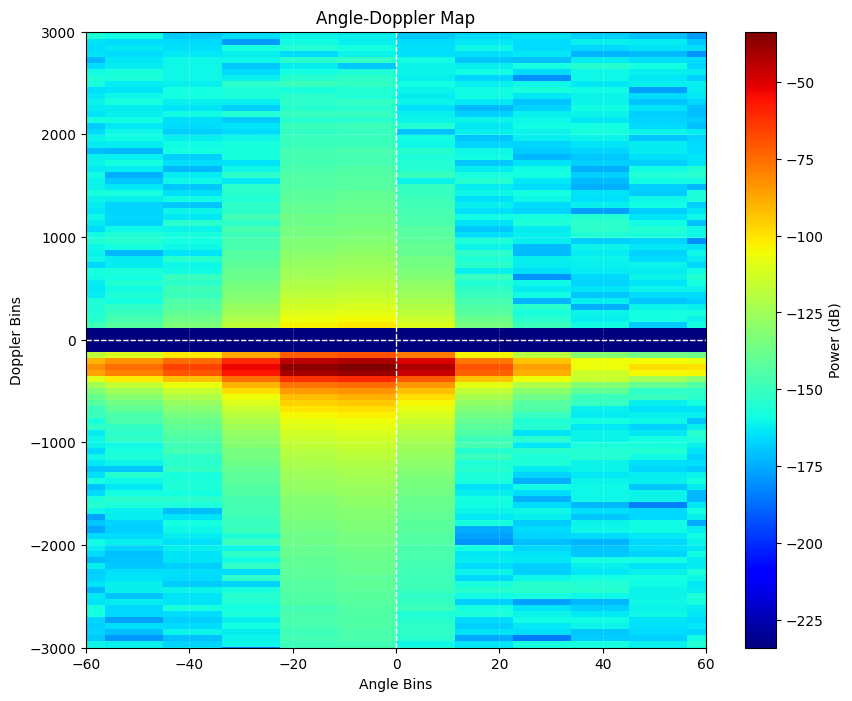

--- RAPORT DETEKCJI ---
Kąt (Azimuth): -6.00 stopni
Przesunięcie Dopplera: -264.19 Hz


In [17]:
scene = load_scene("./OpenStreetMap/kampus_AGH_doppler/Kampus_AGH_B9_doppler.xml", merge_shapes=False)

# # Tworzenie materiału udającego ludzkie ciało
human_flesh = RadioMaterial("human_flesh", relative_permittivity=45.0, conductivity=1.5, scattering_coefficient=0.2, color=[1.0, 0.4, 0.8])

if "human_flesh" not in scene.radio_materials:
    scene.add(human_flesh)

# Tworzymy chropowaty metal radarowy
car_material = RadioMaterial("radar_target", relative_permittivity=1.0, conductivity=1e7, scattering_coefficient=0.3, color=[0.5, 0.5, 0.5]) 
# car_material = RadioMaterial("radar_target", relative_permittivity=1.0, conductivity=0.0, scattering_coefficient=0.0, color=[0.5, 0.5, 0.5]) 

# Dodajemy go do sceny (zabezpieczenie przed podwójnym dodaniem)
if "radar_target" not in scene.radio_materials:
    scene.add(car_material)

# Szukamy człowieka i samochodu i robimy z nich idealne cele
for name, obj in scene.objects.items():
    if "Samochod" in name:
        obj.radio_material = "radar_target"

# konfiguracja parametrów anteny dla nadajnika
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

# konfiguracja parametrów anteny dla odbiornika
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=16,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

radar_position = [-9.169, 87.045, 17.500]

# Tworzenie nadajnika
tx = Transmitter(name="tx",
                 position=radar_position,
                 display_radius=3)

# dodanie instancji nadajnika do sceny
scene.add(tx)

# utworzenie odbiornika
rx = Receiver(name="rx",
              position=radar_position,
              display_radius=3)

scene.add(rx)

# pobranie referencji do obiektów człowieka i samochodu
czlowiek = scene.get("Czlowiek_001")
samochod = scene.get("Samochod_001")

czlowiek_velocity = [0, -3, 0.0]
samochod_velocity = [-5, -15, 0.0]

scene.get("Czlowiek_001").velocity = czlowiek_velocity
scene.get("Samochod_001").velocity = samochod_velocity

tx.look_at(czlowiek)
rx.look_at(czlowiek)

# OFDM
num_ofdm_symbols = 512 
num_subcarriers = 512
subcarrier_spacing = 30e3

ofdm_symbol_duration = 1 / subcarrier_spacing
delay_resolution = ofdm_symbol_duration / num_subcarriers
doppler_resolution = subcarrier_spacing / num_ofdm_symbols

frequencies = subcarrier_frequencies(num_subcarriers=num_subcarriers, subcarrier_spacing=subcarrier_spacing)

p_solver = PathSolver()

paths = p_solver(scene=scene, max_depth=3, samples_per_src=5_000_000, diffuse_reflection=True, specular_reflection=True)

# generowanie CFR
h = paths.cfr(frequencies=frequencies, sampling_frequency=1 / ofdm_symbol_duration, num_time_steps=num_ofdm_symbols, normalize=False, out_type="numpy")

# Transformacja do dziedziny Dopplera
h = np.squeeze(h)

# Wyciągamy plaster(16 anten, 512 symboli)
h_2d = h[:, :, 256]

h_angle_doppler_raw = h_2d.T

h_clean = h_angle_doppler_raw - np.mean(h_angle_doppler_raw, axis=0, keepdims=True)

window_time = np.hanning(num_ofdm_symbols)[:, None]
window_space = np.hanning(16)[None, :]
window_2d = window_time * window_space

h_windowed = h_clean * window_2d

ad_map = np.fft.fft2(h_windowed)

ad_map_shifted = np.fft.fftshift(ad_map)

srodek_y = int(ad_map_shifted.shape[0] / 2)

ad_map_shifted[srodek_y-2:srodek_y+2, :] = 1e-12

ad_power_db = 20 * np.log10(np.abs(ad_map_shifted) + 1e-12)

max_doppler_hz = (num_ofdm_symbols / 2) * doppler_resolution

plt.figure(figsize=(10, 8))
plt.imshow(ad_power_db, aspect='auto', origin='lower', cmap='jet', extent=[-90, 90, -max_doppler_hz, max_doppler_hz])

plt.colorbar(label='Power (dB)')
plt.title('Angle-Doppler Map')
plt.xlabel('Angle Bins')
plt.ylabel('Doppler Bins')

plt.ylim(-3000, 3000)

plt.xlim(-60, 60)

plt.grid(color='white', linestyle='--', linewidth=0.5, alpha=0.3)

plt.axhline(0, color='white', linewidth=1, linestyle='--')
plt.axvline(0, color='white', linewidth=1, linestyle='--')

plt.show()

idx_y, idx_x = np.unravel_index(np.argmax(ad_power_db), ad_power_db.shape)

katy_wektor = np.linspace(-90, 90, ad_power_db.shape[1])
wykryty_kat = katy_wektor[idx_x]

dopplery_wektor = np.linspace(-max_doppler_hz, max_doppler_hz, ad_power_db.shape[0])
wykryta_predkosc_hz = dopplery_wektor[idx_y]

print("--- RAPORT DETEKCJI ---")
print(f"Kąt (Azimuth): {wykryty_kat:.2f} stopni")
print(f"Przesunięcie Dopplera: {wykryta_predkosc_hz:.2f} Hz")